# M9: reliability-first outcome selection

Implements proposal 5 from `docs/ssvep_analyses.md` (PLAN milestone M9): pick
the primary outcome measure by how reliably it reproduces test-retest, not by
how appealing it looks. Two ideas do the work -- **ICC** (does a measure give
the same answer for the same person twice?) and **minimum detectable effect**
(how much does an unreliable measure raise the bar for what you could ever
detect?). Both get a synthetic walkthrough before touching real data, since
they're the concepts this notebook needs you to carry forward into every
future outcome-measure decision.

In [1]:
import sys
sys.path.append('../scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import analysis as an
import reliability as rel
from plotting import DISTRIBUTION_COLOR

runmap_df = an.load_runmap()
baselines_df = an.load_baselines()
metadata_df = an.load_metadata()

## Concept 1: what ICC actually measures

Intraclass correlation asks a simple question: if you measured the same
group of people twice, how much of the *total* spread in the numbers is
"real" (differences between people) versus "noise" (the same person coming
out different each time)? `ICC = between-subject variance / (between-subject
variance + within-subject variance)`. ICC near 1 means repeat measurements on
one person cluster tightly compared to the spread across people -- a
reliable ruler. ICC near 0 means a second measurement on the same person is
about as different from the first as a measurement on a random other person
-- the ruler is mostly noise.

**Why this is exactly `variance.py`'s within/between split (M7), just
between sessions instead of between runs.** Same decomposition, different
pair of repeated measurements.

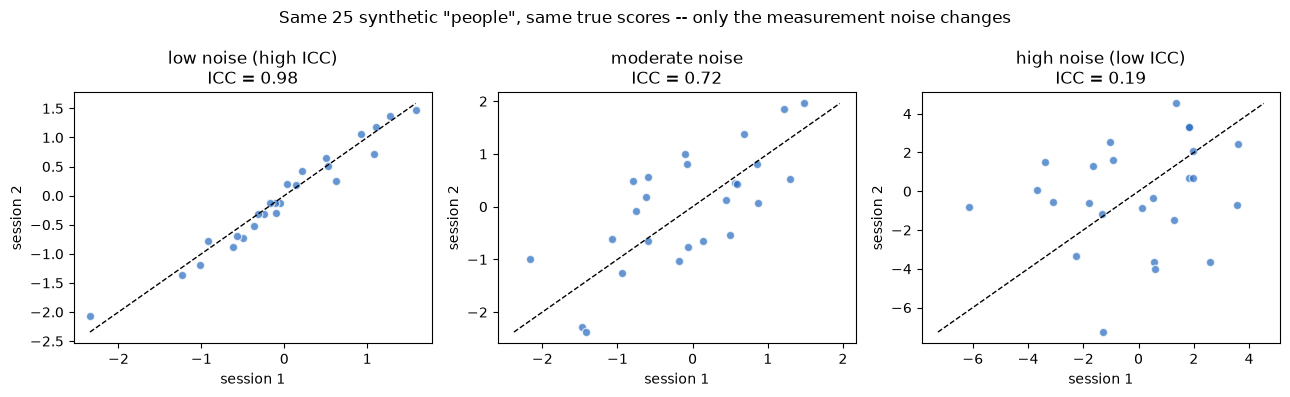

In [2]:
rng = np.random.default_rng(0)
n_subjects = 25
true_scores = rng.normal(0, 1, size=n_subjects)  # each "person's" real, stable value

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, noise_sd, label in zip(axes, [0.15, 0.7, 2.5], ['low noise (high ICC)', 'moderate noise', 'high noise (low ICC)']):
    session1 = true_scores + rng.normal(0, noise_sd, size=n_subjects)
    session2 = true_scores + rng.normal(0, noise_sd, size=n_subjects)
    icc = rel.feature_icc(session1, session2)['icc']
    ax.scatter(session1, session2, color=DISTRIBUTION_COLOR, alpha=0.7, edgecolor='white')
    lo, hi = min(session1.min(), session2.min()), max(session1.max(), session2.max())
    ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{label}\nICC = {icc:.2f}')
    ax.set_xlabel('session 1')
    ax.set_ylabel('session 2')
fig.suptitle('Same 25 synthetic "people", same true scores -- only the measurement noise changes')
fig.tight_layout()

Same 25 underlying people in all three panels -- literally the same
`true_scores` array. All that changes is how much noise gets added on top
each "session". Low noise: points hug the diagonal, ICC is high, a second
measurement tells you almost exactly what the first one said. High noise:
the diagonal relationship disappears into a cloud, ICC collapses toward 0 --
a second measurement on the same subject barely predicts the first. This is
the whole test-retest question in one picture, and it's exactly what
`reliability.feature_icc` computes on the real per-subject features below,
and what `reliability.icc_grid` already computed per pixel in
`07_test_retest_reliability.ipynb`.

## Concept 2: why unreliability caps what you can ever detect

A noisy ruler doesn't just add uncertainty -- it systematically shrinks any
real group difference toward zero on the scale you actually observe. If a
feature's true values differ between two groups by some real amount, but
you're measuring that feature through noise, the *observed* group difference
comes out smaller than the true one, and by more as reliability drops. This
is `reliability.minimum_detectable_effect`'s attenuation correction:
`d_observed = d_true * sqrt(ICC)`.

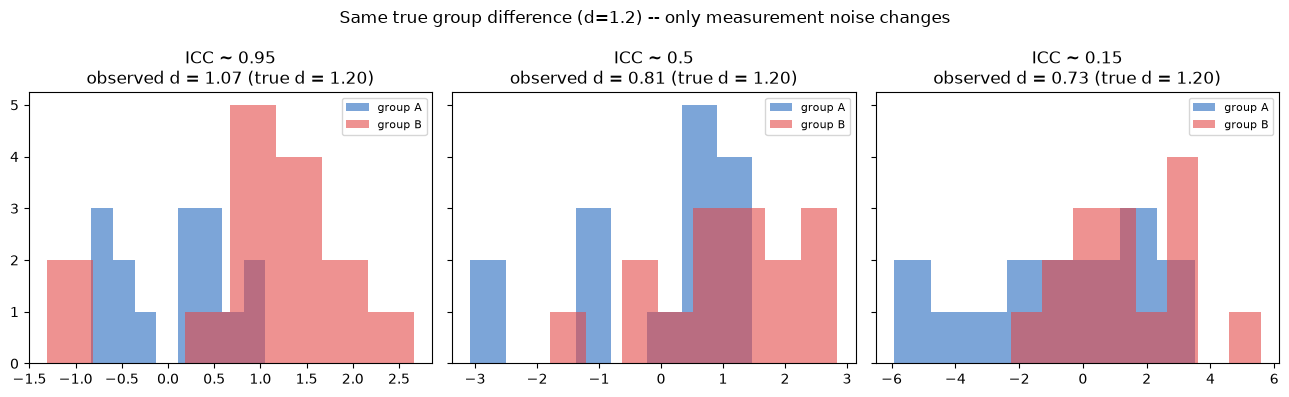

In [3]:
rng = np.random.default_rng(1)
n_per_group = 15
true_diff = 1.2  # a real, fixed difference between two groups, in true-score units

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, icc_target, label in zip(axes, [0.95, 0.5, 0.15], ['ICC ~ 0.95', 'ICC ~ 0.5', 'ICC ~ 0.15']):
    # pick a noise SD that lands near the target ICC for this sample
    noise_sd = np.sqrt(1 / icc_target - 1)
    true_a = rng.normal(0, 1, n_per_group)
    true_b = rng.normal(true_diff, 1, n_per_group)
    observed_a = true_a + rng.normal(0, noise_sd, n_per_group)
    observed_b = true_b + rng.normal(0, noise_sd, n_per_group)
    observed_d = (observed_b.mean() - observed_a.mean()) / np.sqrt((observed_a.var(ddof=1) + observed_b.var(ddof=1)) / 2)
    ax.hist(observed_a, bins=8, alpha=0.6, color=DISTRIBUTION_COLOR, label='group A')
    ax.hist(observed_b, bins=8, alpha=0.6, color='#e34948', label='group B')
    ax.set_title(f'{label}\nobserved d = {observed_d:.2f} (true d = {true_diff:.2f})')
    ax.legend(fontsize=8)
fig.suptitle('Same true group difference (d=1.2) -- only measurement noise changes')
fig.tight_layout()

Same true 1.2-SD group difference baked into every panel. At ICC~0.95 the
observed difference (d=1.07) is close to the true one. As ICC drops, the
*same* true difference shows up smaller in what you'd actually measure
(d=0.81, then d=0.73) -- not because the effect changed, but because
measurement noise inflates both groups' observed spread, which shrinks any
standardized difference computed on top of it. At n=15 per group there's
also plain sampling noise layered on top of the attenuation (rerun this cell
with a different seed and the exact numbers move around), but the direction
is systematic: lower ICC means lower observed d on average, for the same
real effect. `minimum_detectable_effect` runs this logic in reverse: given
your actual n and a feature's actual ICC, what's the smallest *true* effect
that could still survive enough attenuation to be observed? That number is
what makes reliability-first outcome selection a power argument, not just a
"nicer" way to pick a favorite measure.

## Real data: ICC for six candidate outcome features

Three features have no validity gate and are defined for every paired
subject (`depth` from `trough_location`'s argmin; `ramp_slope_red` from M6's
`fit_ramp`; `gain` from M8's `fit_gain_shape` against the CTR template).
Three depend on `fit_ramp_gaussian` locating an actual dip (`fitted_green`,
`fitted_amp`, `fitted_red`) -- restricted to the 14 subjects where that fit
was `fitted_valid` at **both** sessions, matching how `docs/ssvep_analyses.md`
proposal 5 originally computed these (this is also why this notebook's ICC
numbers for those three won't exactly match that document's plain Pearson
correlations -- different statistic, same subject filter, same qualitative
story).

In [4]:
troughs_df = pd.read_csv('../files/subject_troughs.csv', keep_default_na=False)
t = troughs_df.set_index(['sub_id', 'session'])

all_paired = rel.paired_subjects(metadata_df)
valid_both = [s for s in all_paired if t.loc[(s, 1), 'fitted_valid'] and t.loc[(s, 2), 'fitted_valid']]
print(f'paired subjects: {len(all_paired)} total, {len(valid_both)} with a valid ramp_gaussian fit at both sessions')

template = an.group_grid(runmap_df, baselines_df, metadata_df, 1, group='CTR', normalize=an.DEFAULT_NORMALIZE)

def gain_for(sub_id, session):
    grid = an.mean_grid(runmap_df, baselines_df, sub_id, session, normalize=an.DEFAULT_NORMALIZE)
    return an.fit_gain_shape(grid, template)['gain']

rows = []
for feature, sub_ids in [
    ('depth', all_paired), ('ramp_slope_red', all_paired),
    ('fitted_green', valid_both), ('fitted_amp', valid_both), ('fitted_red', valid_both),
]:
    v1 = np.array([t.loc[(s, 1), feature] for s in sub_ids])
    v2 = np.array([t.loc[(s, 2), feature] for s in sub_ids])
    r = rel.feature_icc(v1, v2)
    rows.append({'feature': feature, 'n_paired': len(sub_ids), **r})

gain1 = np.array([gain_for(s, 1) for s in all_paired])
gain2 = np.array([gain_for(s, 2) for s in all_paired])
rows.append({'feature': 'gain', 'n_paired': len(all_paired), **rel.feature_icc(gain1, gain2)})

icc_df = pd.DataFrame(rows).sort_values('icc', ascending=False).reset_index(drop=True)
icc_df[['feature', 'n_paired', 'icc', 'ci_lower', 'ci_upper', 'pval']]

paired subjects: 19 total, 14 with a valid ramp_gaussian fit at both sessions


,feature,n_paired,icc,ci_lower,ci_upper,pval
0,gain,19,0.895291,0.75,0.96,3.998034e-08
1,ramp_slope_red,19,0.848509,0.65,0.94,1.280403e-06
2,depth,19,0.763684,0.48,0.90,6.138545e-05
3,fitted_amp,14,0.489187,-0.05,0.80,3.644002e-02
4,fitted_green,14,0.435808,-0.08,0.77,5.124880e-02
5,fitted_red,14,0.179103,-0.42,0.65,2.741948e-01


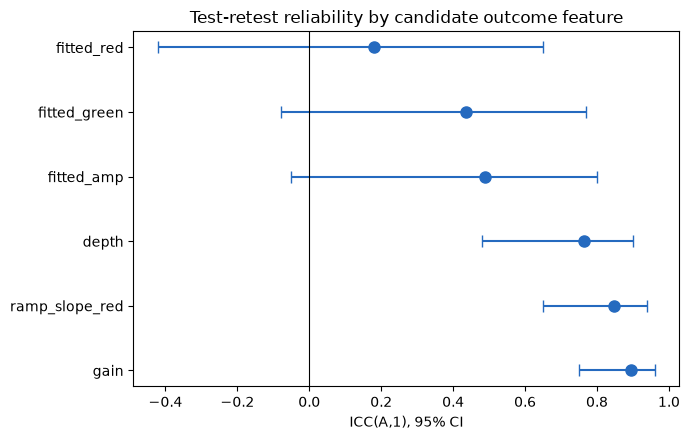

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
y = np.arange(len(icc_df))
ax.errorbar(icc_df['icc'], y, xerr=[icc_df['icc'] - icc_df['ci_lower'], icc_df['ci_upper'] - icc_df['icc']],
            fmt='o', color=DISTRIBUTION_COLOR, capsize=4, markersize=8)
ax.set_yticks(y)
ax.set_yticklabels(icc_df['feature'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('ICC(A,1), 95% CI')
ax.set_title('Test-retest reliability by candidate outcome feature')
fig.tight_layout()

**This changes the recommendation.** `depth` (ICC=0.76) was the best of the
original 4 candidates and the previous primary-outcome recommendation --
still solid. But `ramp_slope_red` (0.85) and `gain` (0.90), both added since
M6/M8, are *more* reliable than `depth`, not just comparably reliable.
`fitted_red` remains the worst by a wide margin (0.18) -- unusable, confirming
the earlier finding on a proper per-subject-feature basis rather than the
document's original hand-computed correlation.

## Real data: minimum detectable effect at this project's actual sample sizes

For the two comparisons this project actually cares about --
PD vs. CTR (n=6, 21) and protan vs. deutan (n=8, 7) -- what's the smallest
*true* effect each feature could ever detect, given its own ICC? ICC values
at or below 0 are clipped to a small positive floor purely so the MDE
formula stays finite for display -- an ICC that low means "not usable",
not literally computable as a detection threshold.

In [6]:
icc_df['icc_for_mde'] = icc_df['icc'].clip(lower=0.05)
icc_df['mde_pd_vs_ctr'] = icc_df['icc_for_mde'].apply(lambda icc: rel.minimum_detectable_effect(6, 21, icc=icc))
icc_df['mde_protan_vs_deutan'] = icc_df['icc_for_mde'].apply(lambda icc: rel.minimum_detectable_effect(8, 7, icc=icc))
ideal_pd_ctr = rel.minimum_detectable_effect(6, 21, icc=1.0)
ideal_protan_deutan = rel.minimum_detectable_effect(8, 7, icc=1.0)
print(f'ideal (ICC=1) MDE -- PD vs CTR: {ideal_pd_ctr:.2f}, protan vs deutan: {ideal_protan_deutan:.2f}')
icc_df[['feature', 'icc', 'mde_pd_vs_ctr', 'mde_protan_vs_deutan']]

ideal (ICC=1) MDE -- PD vs CTR: 1.30, protan vs deutan: 1.45


,feature,icc,mde_pd_vs_ctr,mde_protan_vs_deutan
0,gain,0.895291,1.370624,1.532404
1,ramp_slope_red,0.848509,1.407901,1.574081
2,depth,0.763684,1.484033,1.659199
3,fitted_amp,0.489187,1.854228,2.073090
4,fitted_green,0.435808,1.964504,2.196382
5,fitted_red,0.179103,3.064428,3.426135


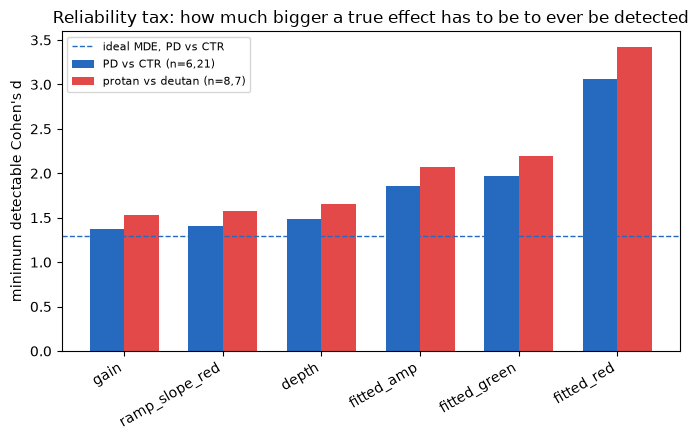

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(icc_df))
width = 0.35
ax.bar(x - width / 2, icc_df['mde_pd_vs_ctr'], width, label='PD vs CTR (n=6,21)', color=DISTRIBUTION_COLOR)
ax.bar(x + width / 2, icc_df['mde_protan_vs_deutan'], width, label='protan vs deutan (n=8,7)', color='#e34948')
ax.axhline(ideal_pd_ctr, color=DISTRIBUTION_COLOR, linestyle='--', linewidth=1, label='ideal MDE, PD vs CTR')
ax.set_xticks(x)
ax.set_xticklabels(icc_df['feature'], rotation=30, ha='right')
ax.set_ylabel("minimum detectable Cohen's d")
ax.legend(fontsize=8)
ax.set_title('Reliability tax: how much bigger a true effect has to be to ever be detected')
fig.tight_layout()

Every bar sits above its comparison's ideal-measure dashed line -- that gap
*is* the cost of imperfect reliability, in the same units (Cohen's d) as
every effect size already reported in this project. `fitted_red` needs a
true effect over d=3 to ever be detectable at PD-vs-CTR's n -- for
comparison, the largest effect size seen anywhere in this dataset so far
(proposal 1's PD-vs-CTR trough-depth effect) is d=0.45. No realistic
biological effect clears that bar; `fitted_red` is not just "less reliable",
it is functionally unusable as an outcome at this project's sample sizes.
`gain` and `ramp_slope_red`, by contrast, sit closest to the ideal-measure
line for both comparisons.

## Decision

**Primary outcome measure, updated from `depth` to `ramp_slope_red` (or
`gain` where a template-relative measure fits better) for anything involving
the CVD/subtype comparisons M6-M8 are about** -- both are more reliable than
`depth` and were purpose-built for exactly that question (M6's bifold CVD
goal, M8's gain axis). `depth` remains a fine, still-reliable choice for
analyses that aren't specifically about gain/ramp behavior, or for continuity
with the argmin-based literature this project's MATLAB templates came from.
**`fitted_red` should not be used as a primary outcome in any comparison** --
its ICC and MDE are both far outside a usable range at this project's sample
sizes. This has been recorded in `docs/methods.md`.